# V35: LQ45 AI Strategy - Basic Statistical Features with TP/FP Optimization

This notebook implements a focused version of the AI strategy using ONLY the core statistical features to capture market volatility and trend. 
It maintains the advanced **TP/FP Ratio Optimization** on the training data to ensure signal quality.

### Feature Set (Strictly Basic):
1. **Vol_20**: 20-day rolling standard deviation of market returns.
2. **Mom_20**: 20-day rolling mean (momentum) of market returns.
3. **Mom_50**: 50-day rolling mean (momentum) of market returns.

### Optimization Logic:
- **Training Data (2023-2024)**: Calculate scores and find the threshold that maximizes the TP/FP ratio.
- **Backtest (2025)**: Apply the found threshold with transaction fees (0.25%).

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data (LQ45) ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1) 

print(f"✓ Data Loaded: {len(data)} rows")

✓ Data Loaded: 712 rows


In [2]:
# --- 2. Feature Engineering (Strictly Basic Stats) ---

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

# Prediction Target: 1-day forward return > 0
target = (market_return.shift(-1) > 0).astype(int)

features = features.dropna()
target = target.reindex(features.index).fillna(0)

train_mask = (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train, y_train = features.loc[train_mask], target.loc[train_mask]
X_test = features.loc[test_mask]

print(f"Training with features: {list(features.columns)}")
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# TP/FP Optimization on Training Set
train_probs = xgb_model.predict_proba(X_train)[:, 1]
thresholds = np.arange(0.40, 0.71, 0.01)
ratios = []
for t in thresholds:
    preds = (train_probs >= t).astype(int)
    if np.sum(preds) == 0: ratios.append(0); continue
    tn, fp, fn, tp = confusion_matrix(y_train, preds).ravel()
    ratios.append(tp / fp if fp > 0 else tp)

opt_t = thresholds[np.argmax(ratios)]
print(f"Optimal Threshold for Basic Features: {opt_t:.2f} (Max TP/FP Ratio: {max(ratios):.2f})")

Training with features: ['Vol_20', 'Mom_20', 'Mom_50']
Optimal Threshold for Basic Features: 0.65 (Max TP/FP Ratio: 94.00)


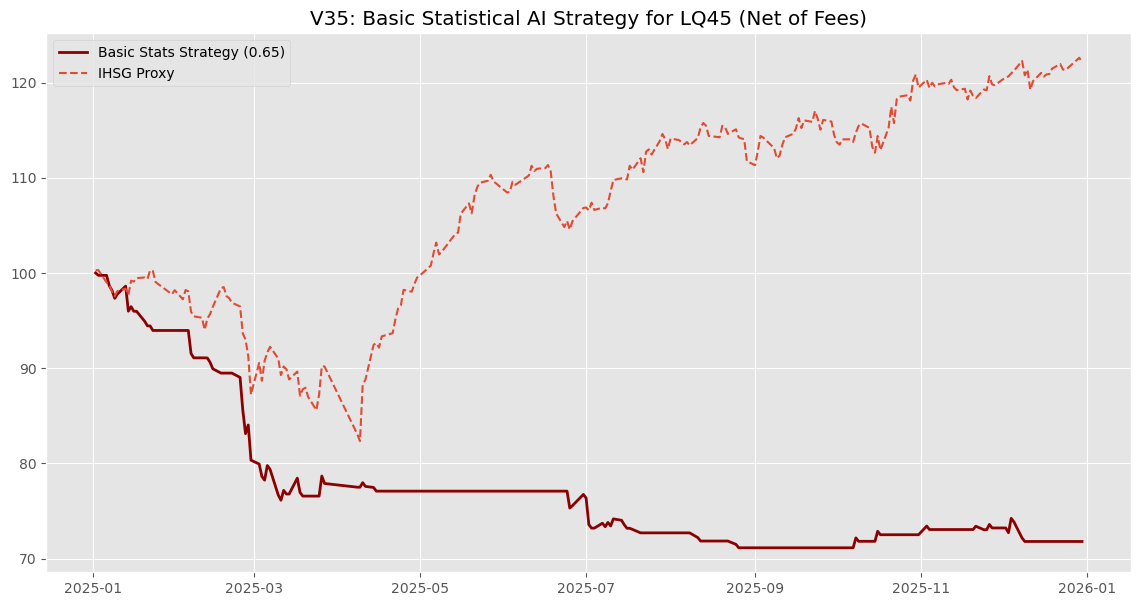

In [3]:
# --- 3. Simulation Logic (0.25% Fee) ---

def get_mis_assets(returns_window, correlation_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    G.add_nodes_from(returns_window.columns)
    for i in range(len(returns_window.columns)):
        for j in range(i+1, len(returns_window.columns)):
            if abs(corr_mat.iloc[i, j]) > correlation_threshold: G.add_edge(returns_window.columns[i], returns_window.columns[j])
    return list(nx.approximation.maximum_independent_set(G))

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    def neg_sharpe(weights):
        p_ret = np.sum(weights * mu)
        p_vol = np.sqrt(np.dot(weights.T, np.dot(sigma, weights)))
        return -p_ret / p_vol if p_vol > 0.0001 else 0
    res = minimize(neg_sharpe, [1./len(mu)]*len(mu), method='SLSQP', bounds=tuple((0, 1) for _ in range(len(mu))), constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def run_simulation(test_dates, returns, ai_probs, threshold=0.5, fee=0.0025):
    val, history, dates = 100.0, [100.0], [test_dates[0]]
    prev_weights = {}
    for i, date in enumerate(test_dates[:-1]):
        is_risk_off = ai_probs.loc[date] < threshold
        if is_risk_off: weights = {'CASH': 1.0}
        else:
            idx_loc = returns.index.get_loc(date)
            window_rets = returns.iloc[idx_loc-30:idx_loc]
            selected = get_mis_assets(window_rets)
            weights = optimize_markowitz(window_rets[selected])
        
        all_assets = set(list(weights.keys()) + list(prev_weights.keys()))
        val -= (val * sum(abs(weights.get(a, 0) - prev_weights.get(a, 0)) for a in all_assets) * fee)
        day_ret = 0 if 'CASH' in weights else sum(w * returns.loc[test_dates[i+1], a] for a, w in weights.items())
        val *= (1 + day_ret)
        history.append(val); dates.append(next_date := test_dates[i+1]); prev_weights = weights
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

test_dates = X_test.index
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=test_dates)
res_opt = run_simulation(test_dates, returns, test_probs, threshold=opt_t)
benchmark = pd.DataFrame({'Portfolio_Value': (market_return.loc[test_dates].cumsum().apply(np.exp) * 100)}, index=test_dates)

plt.figure(figsize=(14, 7))
plt.plot(res_opt.index, res_opt['Portfolio_Value'], label=f"Basic Stats Strategy ({opt_t:.2f})", color='darkred', linewidth=2)
plt.plot(benchmark.index, benchmark['Portfolio_Value'], label="IHSG Proxy", linestyle='--')
plt.title("V35: Basic Statistical AI Strategy for LQ45 (Net of Fees)")
plt.legend()
plt.show()